In [118]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

PLOTS_DIR = Path("../plots")           # relatif dari notebooks/
PLOTS_DIR.mkdir(exist_ok=True)         # bikin folder kalau belum ada

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/spotify_songs.csv") 

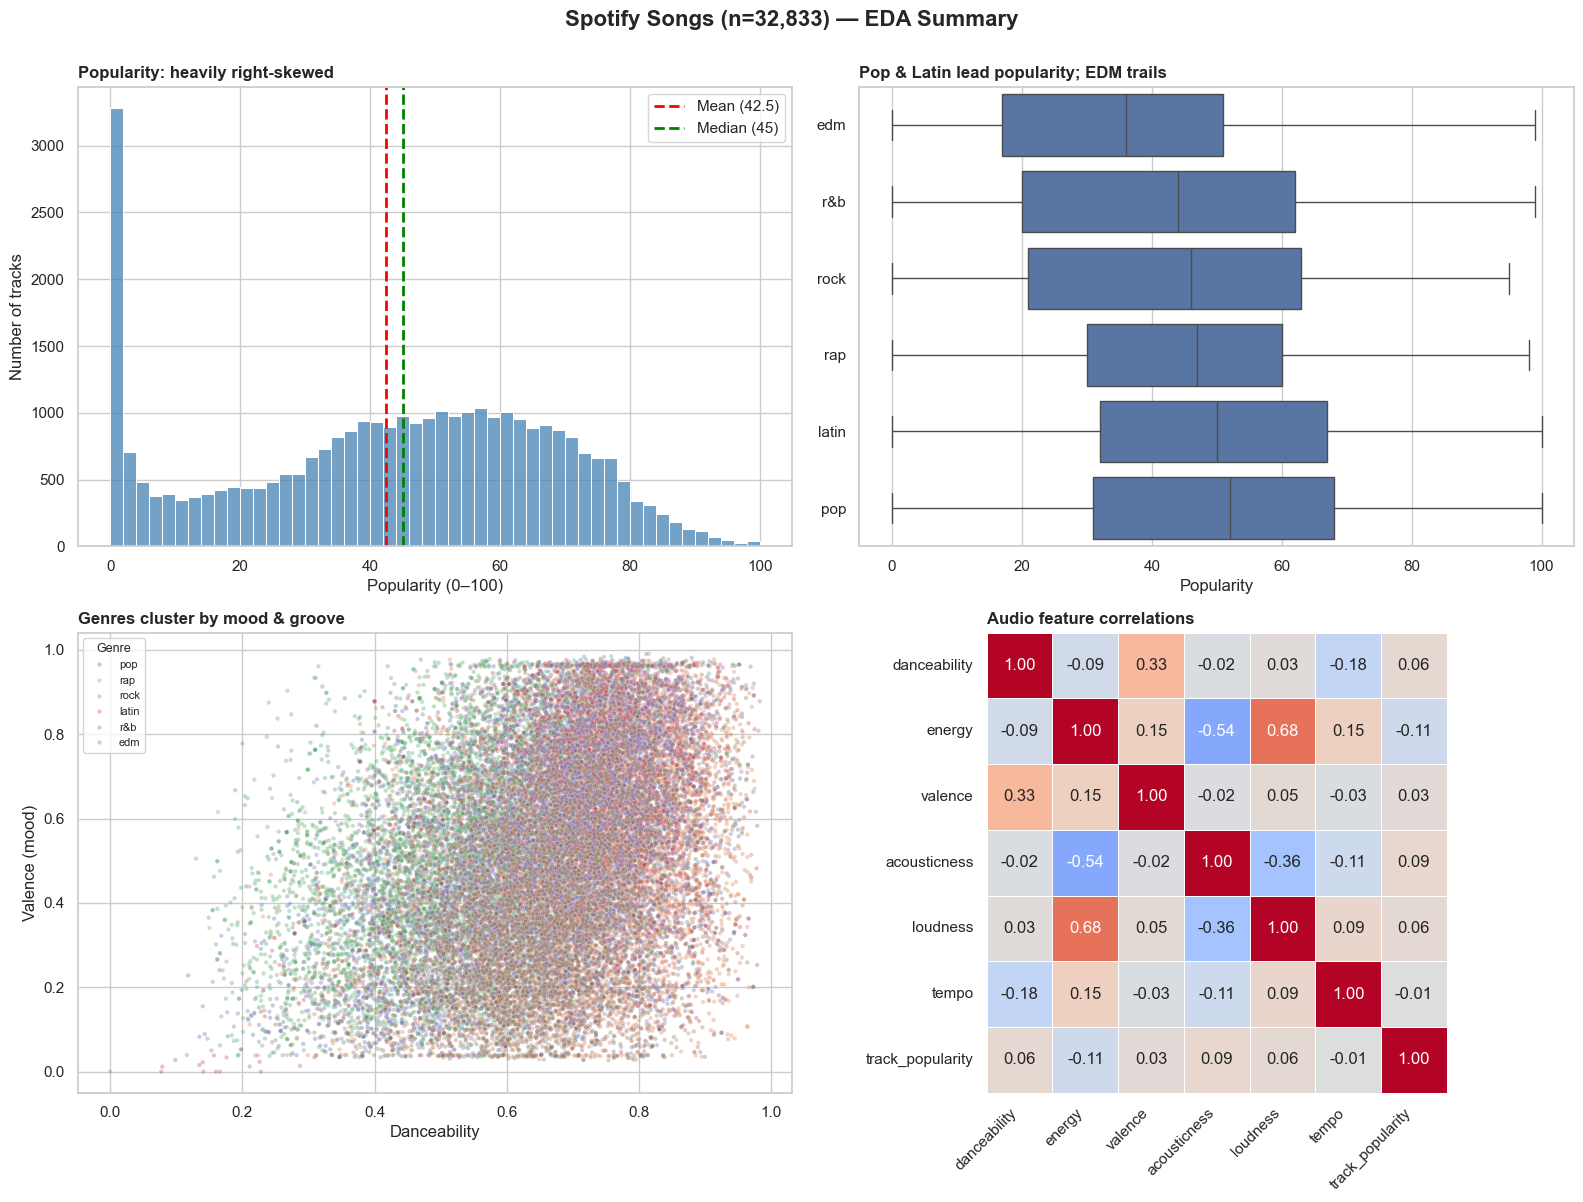

In [119]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Popularity histogram (top-left) ---
sns.histplot(data=df, x="track_popularity", bins=50, ax=axes[0, 0], color="steelblue")
axes[0, 0].axvline(
    df["track_popularity"].mean(),
    color="red", linestyle="--", linewidth=2,
    label=f"Mean ({df['track_popularity'].mean():.1f})",
)
axes[0, 0].axvline(
    df["track_popularity"].median(),
    color="green", linestyle="--", linewidth=2,
    label=f"Median ({df['track_popularity'].median():.0f})",
)
axes[0, 0].set_title("Popularity: heavily right-skewed", fontweight="bold", loc="left")
axes[0, 0].set_xlabel("Popularity (0–100)")
axes[0, 0].set_ylabel("Number of tracks")
axes[0, 0].legend()

# --- Plot 2: Boxplot per genre (top-right) ---
order = (
    df.groupby("playlist_genre")["track_popularity"]
    .median()
    .sort_values(ascending=True)
    .index
)
sns.boxplot(data=df, x="track_popularity", y="playlist_genre", ax=axes[0, 1], order=order)
axes[0, 1].set_title("Pop & Latin lead popularity; EDM trails", fontweight="bold", loc="left")
axes[0, 1].set_xlabel("Popularity")
axes[0, 1].set_ylabel("")

# --- Plot 3: Scatter dance vs valence (bottom-left) ---
sns.scatterplot(
    data=df, x="danceability", y="valence",
    hue="playlist_genre", alpha=0.35, s=10, ax=axes[1, 0],
)
axes[1, 0].set_title("Genres cluster by mood & groove", fontweight="bold", loc="left")
axes[1, 0].set_xlabel("Danceability")
axes[1, 0].set_ylabel("Valence (mood)")
axes[1, 0].legend(title="Genre", loc="upper left", fontsize=8, title_fontsize=9)

# --- Plot 4: Correlation heatmap (bottom-right) ---
features = ["danceability", "energy", "valence", "acousticness", "loudness", "tempo", "track_popularity"]
corr = df[features].corr()
sns.heatmap(
    corr, ax=axes[1, 1],
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    square=True, cbar=False, linewidths=0.5,
)
axes[1, 1].set_title("Audio feature correlations", fontweight="bold", loc="left")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), ha="right")

# --- Header global + layout ---
plt.suptitle(
    "Spotify Songs (n=32,833) — EDA Summary",
    fontsize=16, fontweight="bold", y=1.00,
)
plt.tight_layout()

fig.savefig(PLOTS_DIR / "00_summary_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

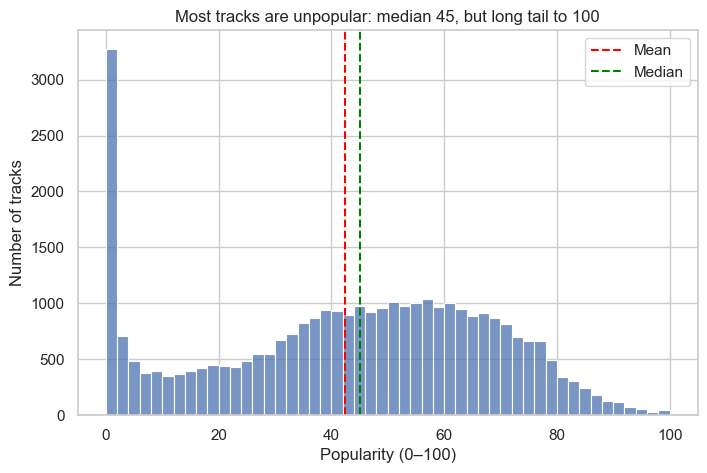

In [120]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
  data=df,
  bins=50,
  x="track_popularity",
  ax=ax
) 
ax.set_xlabel("Popularity (0–100)")
ax.set_ylabel("Number of tracks")
ax.axvline(df["track_popularity"].mean(), label="Mean", color="red", linestyle="--")
ax.axvline(df["track_popularity"].median(), label="Median", color="green", linestyle="--")
ax.legend()
ax.set_title("Most tracks are unpopular: median 45, but long tail to 100")
fig.savefig(PLOTS_DIR / "01_popularity_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

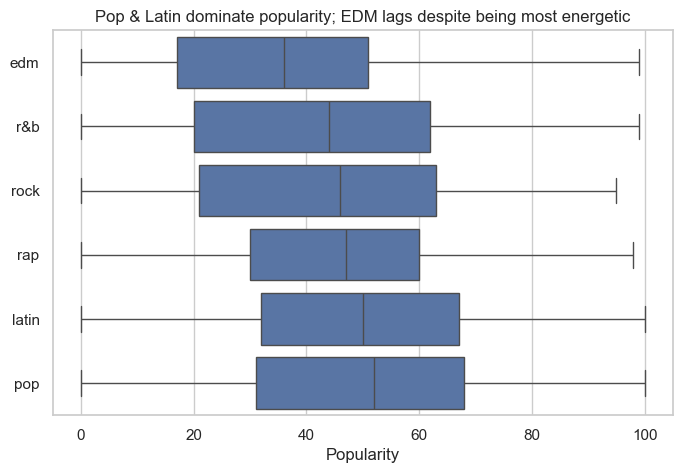

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df.groupby("playlist_genre")["track_popularity"].median().sort_values(ascending=True).index 
sns.boxplot(
  data=df,
  x="track_popularity",
  y="playlist_genre",
  ax=ax,
  order=order, 
)
ax.set_title("Most songs are unpopular — distribution heavily right-skewed\n(mean > median signals long tail of unpopular tracks)")
ax.set_xlabel("Popularity")
ax.set_ylabel("")  # genre udah jelas dari label
ax.set_title("Pop & Latin dominate popularity; EDM lags despite being most energetic")
fig.savefig(PLOTS_DIR / "02_popularity_per_genre_box.png", dpi=150, bbox_inches="tight")
plt.show()

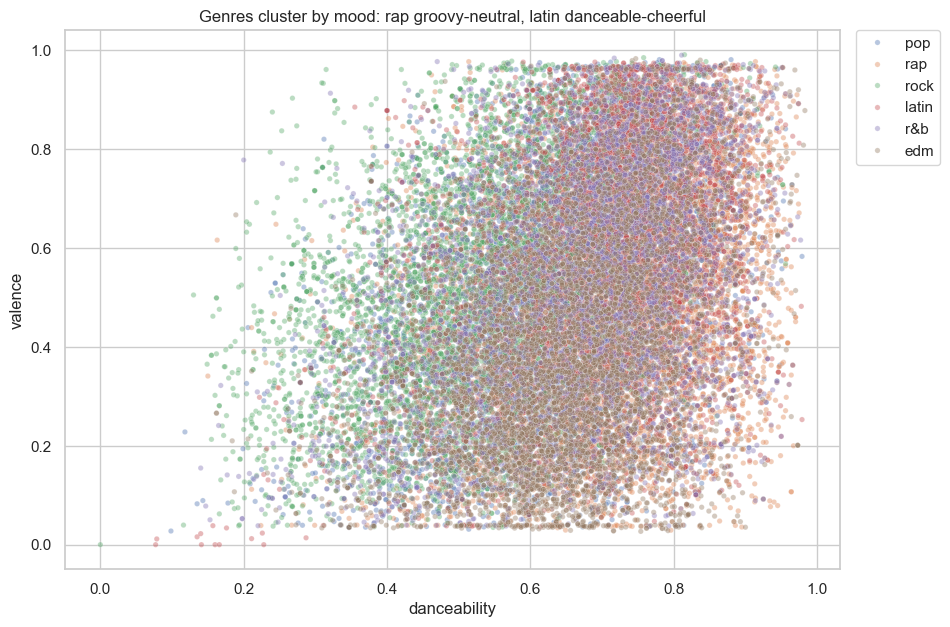

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
  data=df,
  x="danceability",
  y="valence",
  hue="playlist_genre", 
  alpha=0.4, 
  ax=ax,
  s=15
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_title("Genres cluster by mood: rap groovy-neutral, latin danceable-cheerful")
fig.savefig(PLOTS_DIR / "03_audio_features_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

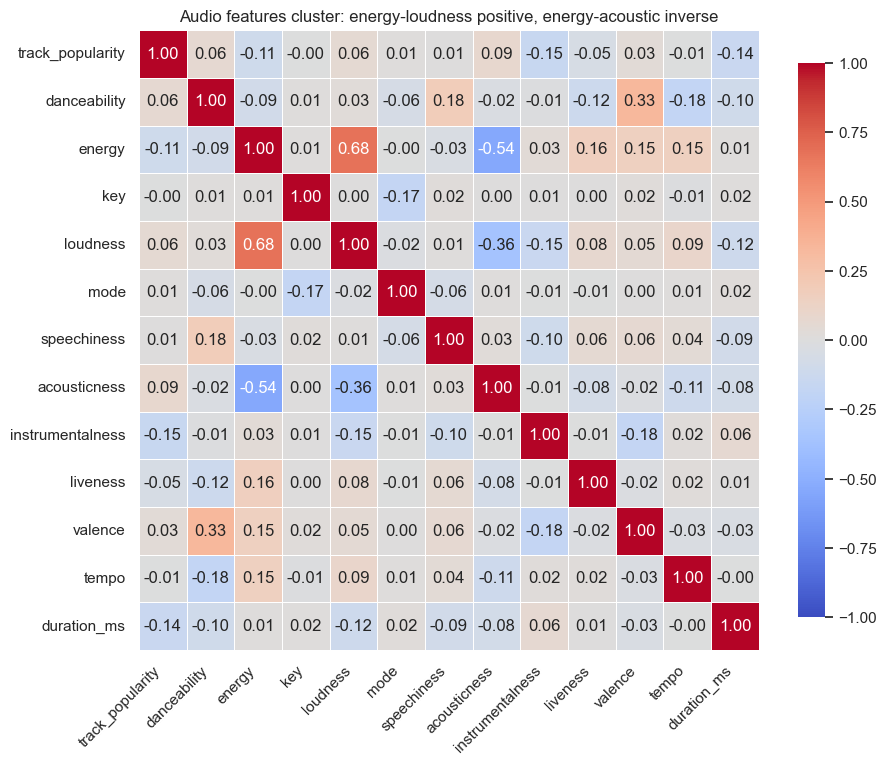

In [123]:
fig, ax = plt.subplots(figsize=(10, 9))
features = df.select_dtypes(include="number").columns
corr = df[features].corr()

sns.heatmap(
  data=corr,
  ax=ax,
  vmin=-1, vmax=1,
  annot=True,
  center=0,
  cmap="coolwarm", 
  fmt=".2f",
  square=True,           # paksa sel jadi square
  linewidths=0.5,        # garis pemisah tipis biar grid lebih jelas
  cbar_kws={"shrink": 0.8},  # colorbar lebih kecil
)
ax.set_title("Audio features cluster: energy-loudness positive, energy-acoustic inverse")
plt.xticks(rotation=45, ha="right")  # rotasi label x biar nggak overlap
fig.savefig(PLOTS_DIR / "04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()